17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training RNN...

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 73ms/step - accuracy: 0.6336 - loss: 0.6215 - val_accuracy: 0.7182 - val_loss: 0.5507
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.8335 - loss: 0.3847 - val_accuracy: 0.6800 - val_loss: 0.5911
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.8885 - loss: 0.2706 - val_accuracy: 0.7882 - val_loss: 0.5142
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7963 - loss: 0.5012

Training LSTM...

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 142ms/step - accuracy: 0.7939 - loss: 0.4405 - val_accuracy: 0.8542 - val_loss: 0.3426
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 145ms/step - accuracy: 0.9036 - loss: 0.2460 - val_accuracy: 0.8736 - val_loss: 0.3047
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 140ms/step - accuracy: 0.9280 - loss: 0.1917 - val_accuracy: 0.8462 - val_loss: 0.3573
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.8472 - loss: 0.3625

Training GRU...

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s

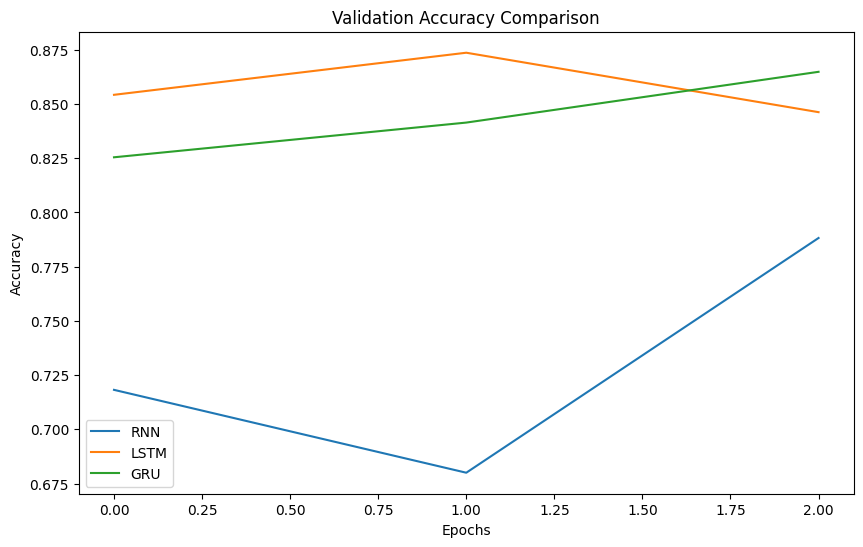


Final Test Accuracy:
RNN: 79.63%
LSTM: 84.72%
GRU: 86.04%


In [1]:
# ==============================
# Step 1: Import Libraries
# ==============================
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Embedding
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

# ==============================
# Step 2: Load Dataset
# ==============================
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

# ==============================
# Step 3: Model Builder Function
# ==============================
def build_model(model_type):
    model = Sequential()
    model.add(Embedding(vocab_size, 64, input_length=max_len))

    if model_type == "RNN":
        model.add(SimpleRNN(64))
    elif model_type == "LSTM":
        model.add(LSTM(64))
    elif model_type == "GRU":
        model.add(GRU(64))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

    return model

# ==============================
# Step 4: Train Models
# ==============================
models = ["RNN", "LSTM", "GRU"]
history_dict = {}
results = {}

for m in models:
    print(f"\nTraining {m}...\n")
    model = build_model(m)

    history = model.fit(x_train, y_train,
                        epochs=3,
                        batch_size=64,
                        validation_split=0.2,
                        verbose=1)

    loss, acc = model.evaluate(x_test, y_test)

    history_dict[m] = history
    results[m] = acc

# ==============================
# Step 5: Plot Accuracy
# ==============================
plt.figure(figsize=(10,6))

for m in models:
    plt.plot(history_dict[m].history['val_accuracy'], label=m)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# ==============================
# Step 6: Print Final Results
# ==============================
print("\nFinal Test Accuracy:")
for m in results:
    print(f"{m}: {results[m]*100:.2f}%")